# 📊 Notebook 1: Data Ingestion
## LAFIAKALO Holistic Health ML Model

**Purpose**: Load all pre-parsed health data CSVs, merge overlapping sources, and produce unified processed files.

**Data Sources** (already parsed by scripts):
1. **Flowsheets** — `all_flowsheet_sessions.csv` (1,792 sessions, 2016→2026), `flowsheet_readings.csv` (15,711), `flowsheet_vomit_log.csv` (1,289)
2. **Records.xlsx** — `records_lab.csv` (8,969), `records_food.csv` (3,506), `records_poop.csv` (2,113), `records_physicians.csv`, `records_home_health.csv`
3. **PDF Labs** — `pdf_labs_extracted.csv` (853 results from DaVita reports)
4. **Firestore (ALAFIA.APP)** — nutrition (597), medications (944), elimination (438), lab_results (388), vitals (15), dialysis sessions/readings

**Date Range**: April 2016 – February 2026 (~10 years)

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
EXCEL_DIR = RAW_DIR / 'excel'
PDF_DIR = RAW_DIR / 'pdf'
API_DIR = RAW_DIR / 'api'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Output:       {PROCESSED_DIR}")
print(f"\nAvailable raw CSV files:")
for subdir in [EXCEL_DIR, API_DIR, PDF_DIR]:
    csvs = sorted(subdir.glob('*.csv'))
    if csvs:
        print(f"\n  {subdir.relative_to(PROJECT_ROOT)}/")
        for f in csvs:
            size = f.stat().st_size / 1024
            print(f"    {f.name:45s} {size:>8.1f} KB")

Project root: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML
Raw data:     /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/raw
Output:       /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/processed

Available raw CSV files:

  data/raw/excel/
    all_flowsheet_sessions.csv                       702.1 KB
    early_flowsheet_sessions.csv                      20.0 KB
    flowsheet_readings.csv                          1033.1 KB
    flowsheet_sessions.csv                           640.2 KB
    flowsheet_vomit_log.csv                          134.1 KB
    records_early_flowsheets_raw.csv                  58.8 KB
    records_food.csv                                 412.0 KB
    records_home_health.csv                            2.3 KB
    records_lab.csv                                  326.5 KB
    records_machine.csv                               58.8 KB
    records_physicians.csv                             0.9 KB
    records_poop.csv                                  

---
## 1. Load All Pre-Parsed Data Sources

In [2]:
# ─── 1a. Flowsheet data (2016-2026) ───
sessions = pd.read_csv(EXCEL_DIR / 'all_flowsheet_sessions.csv', parse_dates=['session_date'])
readings = pd.read_csv(EXCEL_DIR / 'flowsheet_readings.csv')
vomit_log = pd.read_csv(EXCEL_DIR / 'flowsheet_vomit_log.csv')

print("=== FLOWSHEET DATA ===")
print(f"  Sessions:    {len(sessions):>6,}  ({sessions['session_date'].min().date()} → {sessions['session_date'].max().date()})")
print(f"  Readings:    {len(readings):>6,}")
print(f"  Vomit log:   {len(vomit_log):>6,}")

# ─── 1b. Records.xlsx data ───
records_lab = pd.read_csv(EXCEL_DIR / 'records_lab.csv')
records_food = pd.read_csv(EXCEL_DIR / 'records_food.csv')
records_poop = pd.read_csv(EXCEL_DIR / 'records_poop.csv')
records_physicians = pd.read_csv(EXCEL_DIR / 'records_physicians.csv')
records_home_health = pd.read_csv(EXCEL_DIR / 'records_home_health.csv')

print("\n=== RECORDS.XLSX DATA ===")
print(f"  Lab results: {len(records_lab):>6,}  (162 tests, {records_lab['date'].nunique()} dates)")
print(f"  Food log:    {len(records_food):>6,}  ({records_food['date'].nunique()} unique dates)")
print(f"  Poop log:    {len(records_poop):>6,}")
print(f"  Physicians:  {len(records_physicians):>6,}")
print(f"  Home health: {len(records_home_health):>6,}")

# ─── 1c. PDF lab results ───
pdf_labs = pd.read_csv(PDF_DIR / 'pdf_labs_extracted.csv')
print(f"\n=== PDF LABS ===")
print(f"  Lab results: {len(pdf_labs):>6,}  ({pdf_labs['date'].nunique()} dates)")

# ─── 1d. Firestore / ALAFIA.APP data ───
fs_nutrition = pd.read_csv(API_DIR / 'nutrition.csv')
fs_medications = pd.read_csv(API_DIR / 'medications.csv')
fs_elimination = pd.read_csv(API_DIR / 'elimination.csv')
fs_lab_results = pd.read_csv(API_DIR / 'lab_results.csv')
fs_vitals = pd.read_csv(API_DIR / 'vitals.csv')
fs_journal = pd.read_csv(API_DIR / 'journal_mood.csv')
fs_symptoms = pd.read_csv(API_DIR / 'symptoms.csv')
fs_dialysis_sessions = pd.read_csv(API_DIR / 'dialysis_sessions.csv')
fs_dialysis_readings = pd.read_csv(API_DIR / 'dialysis_readings.csv')

print(f"\n=== FIRESTORE (ALAFIA.APP) ===")
for name, df in [
    ('Nutrition', fs_nutrition), ('Medications', fs_medications),
    ('Elimination', fs_elimination), ('Lab results', fs_lab_results),
    ('Vitals', fs_vitals), ('Journal/Mood', fs_journal),
    ('Symptoms', fs_symptoms), ('Dialysis sessions', fs_dialysis_sessions),
    ('Dialysis readings', fs_dialysis_readings),
]:
    # Find date range
    dcols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]
    dr = ""
    for dc in dcols[:2]:
        vals = pd.to_datetime(df[dc], errors='coerce').dropna()
        if not vals.empty:
            dr = f"  ({vals.min().date()} → {vals.max().date()})"
            break
    print(f"  {name:20s} {len(df):>6,}{dr}")

=== FLOWSHEET DATA ===
  Sessions:     1,792  (2016-04-28 → 2026-02-17)
  Readings:    15,711
  Vomit log:    1,289

=== RECORDS.XLSX DATA ===
  Lab results:  8,969  (162 tests, 311 dates)
  Food log:     3,506  (1592 unique dates)
  Poop log:     2,113
  Physicians:      17
  Home health:     25

=== PDF LABS ===
  Lab results:    853  (13 dates)

=== FIRESTORE (ALAFIA.APP) ===
  Nutrition               603  (2025-05-28 → 2026-02-19)
  Medications             953  (2025-06-01 → 2026-02-20)
  Elimination             442  (2025-06-01 → 2026-02-19)
  Lab results             388  (2025-01-27 → 2025-08-18)
  Vitals                   15  (2025-07-04 → 2025-11-09)
  Journal/Mood              5  (2025-06-09 → 2025-07-05)
  Symptoms                  1  (2025-10-29 → 2025-10-29)
  Dialysis sessions        21  (2025-06-06 → 2025-07-29)
  Dialysis readings        99  (2025-06-06 → 2025-07-29)


---
## 2. Merge Overlapping Data Sources

Three domains have **overlapping coverage** that must be deduplicated:

| Domain | Records.xlsx | PDF Labs | Firestore | Strategy |
|--------|-------------|----------|-----------|----------|
| **Lab results** | 2016→Feb 2025 | Jan 2025→Feb 2026 | Jan→Aug 2025 | Union-dedup by (date, test, value) |
| **Food/Nutrition** | 2016→Jun 2025 | — | May 2025→Feb 2026 | Concat, dedup by date window |
| **Elimination** | Poop: 2022→May 2025 | — | Jun 2025→Feb 2026 | Append (no overlap) |

In [3]:
# ── 2a. UNIFIED LAB RESULTS ──
# Sources: records_lab (8,969), pdf_labs (853), fs_lab_results (388)
# Strategy: normalize columns → concat → dedup by (date, test_name, value)

# --- Records labs: columns = date, test_name, value, unit, clinical_pref, facility, value_numeric, value_text
rl = records_lab.copy()
rl['date'] = pd.to_datetime(rl['date'], errors='coerce')
rl['source'] = 'records_xlsx'
# Normalize: ensure 'value_numeric' exists
if 'value_numeric' not in rl.columns:
    rl['value_numeric'] = pd.to_numeric(rl['value'], errors='coerce')

# --- PDF labs: columns = date, source_file, code, test_name, result, flag, unit, ref_low, ref_high, status, result_numeric
pl = pdf_labs.copy()
pl['date'] = pd.to_datetime(pl['date'], errors='coerce')
pl['source'] = 'pdf_davita'
# Normalize column names to match records
pl = pl.rename(columns={'result': 'value', 'result_numeric': 'value_numeric'})

# --- Firestore labs: columns = date, panel_name, lab_name, test_name, value, unit, reference_range
fl = fs_lab_results.copy()
fl['date'] = pd.to_datetime(fl['date'], errors='coerce')
fl['source'] = 'firestore'
fl['value_numeric'] = pd.to_numeric(fl['value'], errors='coerce')

print("Column alignment check:")
for label, df in [('Records', rl), ('PDF', pl), ('Firestore', fl)]:
    has = [c for c in ['date', 'test_name', 'value', 'value_numeric', 'unit', 'source'] if c in df.columns]
    print(f"  {label:10s}: {has}")

# Concat all labs (pandas will align on matching column names)
unified_labs = pd.concat([rl, pl, fl], ignore_index=True)

# Clean up test names
unified_labs['test_name'] = unified_labs['test_name'].astype(str).str.strip()
# Drop rows where test_name is NaN or empty or 'nan' or 'Lab' (metadata rows)
mask_bad = unified_labs['test_name'].isin(['nan', '', 'Lab', 'NaN']) | unified_labs['test_name'].isna()
n_bad = mask_bad.sum()
unified_labs = unified_labs[~mask_bad].reset_index(drop=True)

# Dedup: same date + test_name + value → keep first (prefer records > pdf > firestore)
source_priority = {'records_xlsx': 0, 'pdf_davita': 1, 'firestore': 2}
unified_labs['_priority'] = unified_labs['source'].map(source_priority).fillna(9)
unified_labs = unified_labs.sort_values(['date', 'test_name', '_priority'])
before = len(unified_labs)
unified_labs = unified_labs.drop_duplicates(subset=['date', 'test_name', 'value'], keep='first')
unified_labs = unified_labs.drop(columns=['_priority'])

print(f"\n=== UNIFIED LAB RESULTS ===")
print(f"  Removed {n_bad} bad/metadata rows (no test name)")
print(f"  Before dedup: {before:,}")
print(f"  After dedup:  {len(unified_labs):,}")
print(f"  Unique tests: {unified_labs['test_name'].nunique()}")
print(f"  Date range:   {unified_labs['date'].min().date()} → {unified_labs['date'].max().date()}")
print(f"\n  By source:")
print(unified_labs['source'].value_counts().to_string())

Column alignment check:
  Records   : ['date', 'test_name', 'value', 'value_numeric', 'unit', 'source']
  PDF       : ['date', 'test_name', 'value', 'value_numeric', 'unit', 'source']
  Firestore : ['date', 'test_name', 'value', 'value_numeric', 'unit', 'source']

=== UNIFIED LAB RESULTS ===
  Removed 230 bad/metadata rows (no test name)
  Before dedup: 9,980
  After dedup:  9,660
  Unique tests: 341
  Date range:   2016-04-28 → 2026-02-09

  By source:
source
records_xlsx    8734
pdf_davita       783
firestore        143


In [4]:
# ── 2b. UNIFIED NUTRITION / FOOD LOG ──
# Records food: 3,506 entries (2016→Jun 2025)
# Firestore nutrition: 597 entries (May 2025→Feb 2026)
# Overlap window: ~May-Jun 2025

rf = records_food.copy()
rf['date'] = pd.to_datetime(rf['date'], errors='coerce')
rf['source'] = 'records_xlsx'

fn = fs_nutrition.copy()
# Normalize Firestore nutrition column names
print("Firestore nutrition columns:", list(fn.columns))
for c in fn.columns:
    if 'date' in c.lower() or 'time' in c.lower():
        fn = fn.rename(columns={c: 'date'})
        break
if 'date' in fn.columns:
    fn['date'] = pd.to_datetime(fn['date'], errors='coerce')
fn['source'] = 'firestore'

# For overlap period: prefer Firestore (more recent, app-entered)
# Cut Records at May 27 2025, use Firestore from May 28 on
cutoff = pd.Timestamp('2025-05-28')
rf_trimmed = rf[rf['date'] < cutoff]
fn_after = fn[fn['date'] >= cutoff] if 'date' in fn.columns else fn

unified_nutrition = pd.concat([rf_trimmed, fn_after], ignore_index=True)
unified_nutrition = unified_nutrition.sort_values('date').reset_index(drop=True)

print(f"\n=== UNIFIED NUTRITION ===")
print(f"  Records (pre-cutoff): {len(rf_trimmed):,}")
print(f"  Firestore (post):     {len(fn_after):,}")
print(f"  Total:                {len(unified_nutrition):,}")
print(f"  Date range: {unified_nutrition['date'].min().date()} → {unified_nutrition['date'].max().date()}")

Firestore nutrition columns: ['date', 'meal_type', 'food_item', 'start_time', 'end_time', 'pre_meal_weight_kg', 'post_meal_weight_kg', 'calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar', 'sodium', 'potassium', 'calcium', 'iron', 'phosphorus', 'vitamin_d', 'vitamin_b12', 'folic_acid', 'cholesterol', 'ai_summary']

=== UNIFIED NUTRITION ===
  Records (pre-cutoff): 3,491
  Firestore (post):     603
  Total:                4,094
  Date range: 2016-06-14 → 2026-02-19


In [6]:
# ── 2c. UNIFIED ELIMINATION (bowel + vomit) ──
# Records poop: 2,113 entries (Jun 2022→May 2025)
# Firestore elimination: 438 entries (Jun 2025→Feb 2026) — includes poop + vomiting
# Vomit log from flowsheets: 1,289 events (Jan 2021→May 2025)
# All three merged into one unified_elimination

rp = records_poop.copy()
rp['date'] = pd.to_datetime(rp['date'], errors='coerce')
rp['source'] = 'records_xlsx'
rp['type'] = 'bowel'
rp['event_type'] = 'poop'

fe = fs_elimination.copy()
print("Firestore elimination columns:", list(fe.columns))
for c in fe.columns:
    if 'date' in c.lower() or 'time' in c.lower():
        fe = fe.rename(columns={c: 'date'})
        break
if 'date' in fe.columns:
    fe['date'] = pd.to_datetime(fe['date'], errors='coerce')
fe['source'] = 'firestore'
# Firestore has event_type = 'poop' or 'vomiting' — use it to set type
if 'event_type' in fe.columns:
    fe['type'] = fe['event_type'].map({'poop': 'bowel', 'vomiting': 'vomit'}).fillna('bowel')
else:
    fe['type'] = 'bowel'

# Vomit log from flowsheets — merge INTO unified elimination (not separate)
vl = vomit_log.copy()
vl['date'] = pd.to_datetime(vl['date'], errors='coerce')
vl['source'] = 'flowsheet'
vl['type'] = 'vomit'
vl['event_type'] = 'vomiting'
# Map vomit_log columns to unified schema
vl_col_map = {
    'weight_pre_kg': 'pre_weight_kg',
    'weight_post_kg': 'post_weight_kg',
    'visual_content': 'description',
    'last_meal': 'notes',
}
for old_name, new_name in vl_col_map.items():
    if old_name in vl.columns:
        vl[new_name] = vl[old_name]

# Combine all three sources
unified_elimination = pd.concat([rp, fe, vl], ignore_index=True)
unified_elimination = unified_elimination.sort_values('date').reset_index(drop=True)

print(f"\n=== UNIFIED ELIMINATION ===")
print(f"  Total: {len(unified_elimination):,}")
print(f"  Bowel: {(unified_elimination['type']=='bowel').sum():,}")
print(f"  Vomit: {(unified_elimination['type']=='vomit').sum():,}")
print(f"  Sources: {unified_elimination['source'].value_counts().to_dict()}")
print(f"  Date range: {unified_elimination['date'].min().date()} → {unified_elimination['date'].max().date()}")

# ── 2d. UNIFIED MEDICATIONS ──
fm = fs_medications.copy()
print(f"\nFirestore medications columns:", list(fm.columns))
for c in fm.columns:
    if 'date' in c.lower() or 'time' in c.lower() or 'created' in c.lower():
        fm = fm.rename(columns={c: 'date'})
        break
if 'date' in fm.columns:
    fm['date'] = pd.to_datetime(fm['date'], errors='coerce')
fm['source'] = 'firestore'

print(f"\n=== MEDICATIONS ===")
print(f"  Firestore medications: {len(fm):,}")
if 'date' in fm.columns:
    print(f"  Date range: {fm['date'].min().date()} → {fm['date'].max().date()}")

Firestore elimination columns: ['date', 'time', 'event_type', 'description', 'pre_weight_kg', 'post_weight_kg']

=== UNIFIED ELIMINATION ===
  Total: 3,844
  Bowel: 2,469
  Vomit: 1,375
  Sources: {'records_xlsx': 2113, 'flowsheet': 1289, 'firestore': 442}
  Date range: 2021-01-02 → 2026-02-19

Firestore medications columns: ['date', 'time', 'medication_name', 'dosage', 'source_provider', 'pre_bp_systolic', 'pre_bp_diastolic', 'pre_heart_rate', 'post_bp_systolic', 'post_bp_diastolic', 'post_heart_rate', 'notes']

=== MEDICATIONS ===
  Firestore medications: 953
  Date range: 2025-06-01 → 2026-02-20


---
## 3. Dialysis Sessions + Vitals + Supporting Data
Flowsheet sessions are already merged (early 2016-2017 + standard 2018-2026). We also have Firestore dialysis sessions (21) from the app — these overlap with flowsheets so we keep flowsheets as primary.

In [7]:
# ── 3a. DIALYSIS SESSIONS ──
# Primary: all_flowsheet_sessions.csv (1,792 sessions)
# Secondary: Firestore dialysis_sessions (21) — likely overlaps
# Intra-dialysis readings: flowsheet_readings.csv (15,711)

ds = sessions.copy()  # already loaded as 'sessions'
ds['source'] = 'flowsheet'

# Check if Firestore has any unique sessions not in flowsheets
fds = fs_dialysis_sessions.copy()
print("Firestore dialysis_sessions columns:", list(fds.columns))
for c in fds.columns:
    if 'date' in c.lower() or 'session' in c.lower():
        fds = fds.rename(columns={c: 'session_date'})
        break
if 'session_date' in fds.columns:
    fds['session_date'] = pd.to_datetime(fds['session_date'], errors='coerce')
    # Find Firestore sessions NOT in flowsheet dates
    flowsheet_dates = set(ds['session_date'].dt.date)
    fds_unique = fds[~fds['session_date'].dt.date.isin(flowsheet_dates)]
    if len(fds_unique) > 0:
        fds_unique = fds_unique.copy()
        fds_unique['source'] = 'firestore'
        ds = pd.concat([ds, fds_unique], ignore_index=True)
        print(f"  Added {len(fds_unique)} unique Firestore sessions not in flowsheets")
    else:
        print(f"  All {len(fds)} Firestore sessions already covered by flowsheets")

ds = ds.sort_values('session_date').reset_index(drop=True)

print(f"\n=== UNIFIED DIALYSIS SESSIONS ===")
print(f"  Total sessions: {len(ds):,}")
print(f"  Date range:     {ds['session_date'].min().date()} → {ds['session_date'].max().date()}")
print(f"  Intra-dialysis readings: {len(readings):,}")

# ── 3b. VITALS ──
fv = fs_vitals.copy()
print(f"\n=== VITALS (Firestore) ===")
print(f"  Records: {len(fv)}")
print(f"  Columns: {list(fv.columns)}")

# ── 3c. SUPPORTING DATA ──
print(f"\n=== SUPPORTING DATA ===")
print(f"  Physicians:    {len(records_physicians):>4}")
print(f"  Home health:   {len(records_home_health):>4}")
print(f"  Journal/Mood:  {len(fs_journal):>4}")
print(f"  Symptoms:      {len(fs_symptoms):>4}")

Firestore dialysis_sessions columns: ['date', 'doc_id', 'facility', 'prescriber', 'reviewer', 'access_site', 'treatment_start', 'treatment_end', 'total_machine_time', 'pre_weight_kg', 'post_weight_kg', 'target_weight_kg', 'fluid_removed_liters', 'pre_bp_sitting_sys', 'pre_bp_sitting_dia', 'pre_hr_sitting', 'pre_bp_standing_sys', 'pre_bp_standing_dia', 'pre_hr_standing', 'post_bp_sitting_sys', 'post_bp_sitting_dia', 'post_hr_sitting', 'post_bp_standing_sys', 'post_bp_standing_dia', 'post_hr_standing', 'pre_temperature', 'pre_temp_unit', 'post_temperature', 'post_temp_unit', 'total_dialysate_liters', 'total_blood_volume_liters', 'dialyzer_lot', 'dialysate_lot', 'general_notes']
  Added 5 unique Firestore sessions not in flowsheets

=== UNIFIED DIALYSIS SESSIONS ===
  Total sessions: 1,797
  Date range:     2016-04-28 → 2026-02-17
  Intra-dialysis readings: 15,711

=== VITALS (Firestore) ===
  Records: 15
  Columns: ['date', 'bp_systolic', 'bp_diastolic', 'heart_rate', 'body_temperature',

---
## 4. Save Unified Processed Files
Write all merged/deduped data to `data/processed/` for downstream notebooks.

In [8]:
# Create processed directory
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

saved = []

def save_csv(df, name, date_col=None):
    """Save DataFrame to processed dir and track it."""
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    rows = len(df)
    dr = ""
    if date_col and date_col in df.columns:
        dates = pd.to_datetime(df[date_col], errors='coerce').dropna()
        if not dates.empty:
            dr = f"  ({dates.min().date()} → {dates.max().date()})"
    saved.append((name, rows, dr))
    return path

# ── Save all unified datasets ──
save_csv(unified_labs, 'unified_labs.csv', 'date')
save_csv(unified_nutrition, 'unified_nutrition.csv', 'date')
save_csv(unified_elimination, 'unified_elimination.csv', 'date')
save_csv(fm, 'medications.csv', 'date')
save_csv(ds, 'dialysis_sessions.csv', 'session_date')
save_csv(readings, 'dialysis_readings.csv')
save_csv(fv, 'vitals.csv')
save_csv(records_physicians, 'physicians.csv')
save_csv(records_home_health, 'home_health.csv')
save_csv(fs_journal, 'journal_mood.csv')
save_csv(fs_symptoms, 'symptoms.csv')

print("=" * 65)
print("SAVED PROCESSED FILES")
print("=" * 65)
for name, rows, dr in saved:
    print(f"  ✅ {name:30s} {rows:>7,} rows{dr}")
print(f"\nOutput directory: {PROCESSED_DIR}")

SAVED PROCESSED FILES
  ✅ unified_labs.csv                 9,660 rows  (2016-04-28 → 2026-02-09)
  ✅ unified_nutrition.csv            4,094 rows  (2016-06-14 → 2026-02-19)
  ✅ unified_elimination.csv          3,844 rows  (2021-01-02 → 2026-02-19)
  ✅ medications.csv                    953 rows  (2025-06-01 → 2026-02-20)
  ✅ dialysis_sessions.csv            1,797 rows  (2016-04-28 → 2026-02-17)
  ✅ dialysis_readings.csv           15,711 rows
  ✅ vitals.csv                          15 rows
  ✅ physicians.csv                      17 rows
  ✅ home_health.csv                     25 rows
  ✅ journal_mood.csv                     5 rows
  ✅ symptoms.csv                         1 rows

Output directory: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/processed


In [9]:
# ── Quick preview of key datasets ──
print("=" * 65)
print("PREVIEW: Unified Labs (first 10)")
print("=" * 65)
display(unified_labs[['date', 'test_name', 'value', 'value_numeric', 'source']].head(10))

print("\n" + "=" * 65)
print("PREVIEW: Dialysis Sessions (last 10)")
print("=" * 65)
cols_show = [c for c in ds.columns if c in ['session_date', 'pre_weight_kg', 'post_weight_kg',
    'fluid_removed_L', 'pre_sys', 'pre_dia', 'post_sys', 'post_dia', 'source']]
display(ds[cols_show].tail(10))

PREVIEW: Unified Labs (first 10)


,date,test_name,value,value_numeric,source
0,2016-04-28,HCT CALC (HBGX3),0,0.0,records_xlsx
1,2016-04-28,"Reticulocyte Count, Absolute, Automated",145.3,145.3,records_xlsx
2,2016-04-28,"Reticulocytes, Absolute",6.4,6.4,records_xlsx
3,2016-04-28,uRR,#DIV/0!,NaN,records_xlsx
4,2016-04-29,LDH(Total),407,407.0,records_xlsx
5,2016-04-29,"Reticulocyte Count, Absolute, Automated",171.9,171.9,records_xlsx
6,2016-04-29,"Reticulocytes, Absolute",6,6.0,records_xlsx
7,2016-04-29,uRR,#DIV/0!,NaN,records_xlsx
8,2016-04-30,LDH(Total),503,503.0,records_xlsx
9,2016-04-30,"Reticulocyte Count, Absolute, Automated",153.4,153.4,records_xlsx



PREVIEW: Dialysis Sessions (last 10)


,session_date,post_weight_kg,source,pre_weight_kg
1787,2026-01-30,54.0,flowsheet,NaN
1788,2026-02-01,53.9,flowsheet,NaN
1789,2026-02-03,53.3,flowsheet,NaN
1790,2026-02-05,53.7,flowsheet,NaN
1791,2026-02-07,55.3,flowsheet,NaN
1792,2026-02-09,54.7,flowsheet,NaN
1793,2026-02-11,NaN,flowsheet,NaN
1794,2026-02-13,54.5,flowsheet,NaN
1795,2026-02-14,54.6,flowsheet,NaN
1796,2026-02-17,55.0,flowsheet,NaN


---
## 5. Data Coverage Timeline
Visualize the temporal coverage of each data domain to identify gaps.

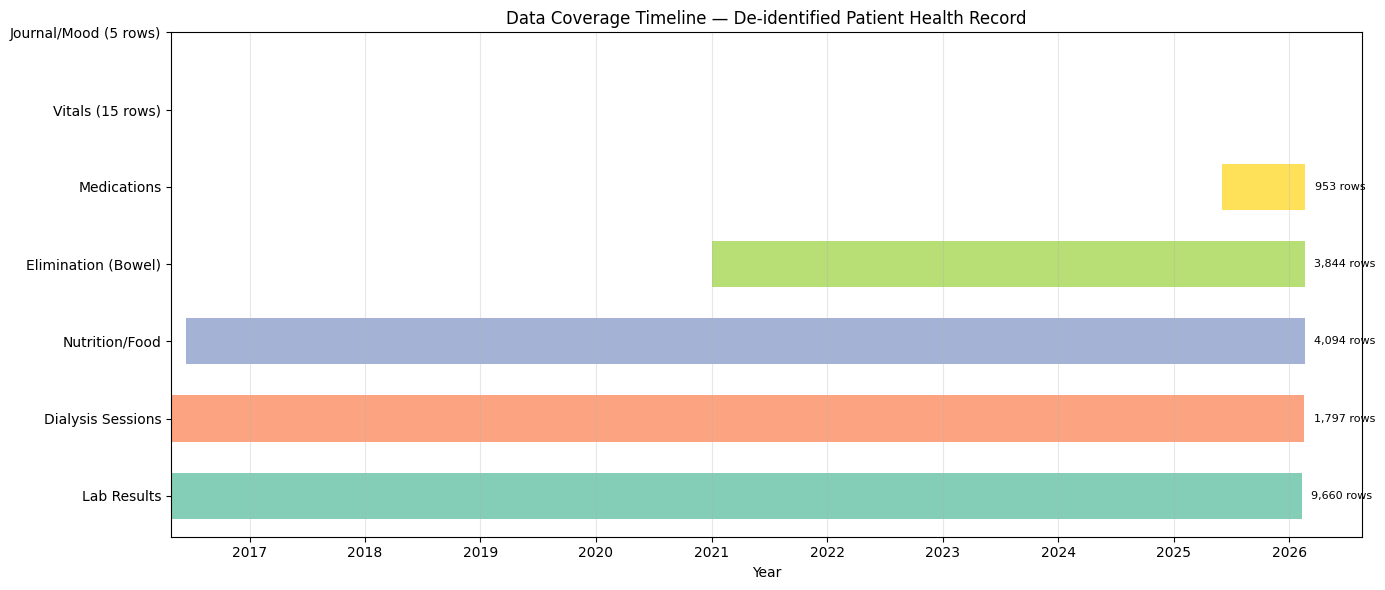

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

domains = [
    ('Lab Results', unified_labs, 'date'),
    ('Dialysis Sessions', ds, 'session_date'),
    ('Nutrition/Food', unified_nutrition, 'date'),
    ('Elimination (Bowel)', unified_elimination, 'date'),
    ('Medications', fm, 'date'),
    ('Vitals', fv, None),
    ('Journal/Mood', fs_journal, None),
]

colors = plt.cm.Set2(np.linspace(0, 1, len(domains)))
y_labels = []

for i, (name, df, dcol) in enumerate(domains):
    if dcol and dcol in df.columns:
        dates = pd.to_datetime(df[dcol], errors='coerce').dropna()
        if not dates.empty:
            ax.barh(i, (dates.max() - dates.min()).days, left=mdates.date2num(dates.min()),
                    height=0.6, color=colors[i], alpha=0.8)
            ax.text(mdates.date2num(dates.max()) + 30, i,
                    f"{len(df):,} rows", va='center', fontsize=8)
            y_labels.append(name)
        else:
            y_labels.append(f"{name} (no dates)")
    else:
        y_labels.append(f"{name} ({len(df)} rows)")

ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Year')
ax.set_title('Data Coverage Timeline — De-identified Patient Health Record')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Data Quality Report

In [11]:
# ── Lab test coverage: which tests have enough data for modeling? ──
test_counts = unified_labs.groupby('test_name').agg(
    n_results=('value', 'count'),
    n_dates=('date', 'nunique'),
    pct_numeric=('value_numeric', lambda x: x.notna().mean() * 100),
    first_date=('date', 'min'),
    last_date=('date', 'max'),
).sort_values('n_results', ascending=False)

print("=" * 75)
print("LAB TEST COVERAGE (top 30 by frequency)")
print("=" * 75)
display(test_counts.head(30))

# Tests with enough longitudinal data for trend analysis (≥10 data points)
good_tests = test_counts[test_counts['n_results'] >= 10]
print(f"\nTests with ≥10 results: {len(good_tests)} / {len(test_counts)}")
print(f"Tests with ≥50 results: {len(test_counts[test_counts['n_results'] >= 50])}")

LAB TEST COVERAGE (top 30 by frequency)


,n_results,n_dates,pct_numeric,first_date,last_date
test_name,,,,,
uRR,231,230,67.099567,2016-04-28,2024-08-16
Hemoglobin,220,218,100.000000,2016-05-14,2025-08-18
Potassium,214,212,100.000000,2016-05-14,2025-08-18
BUN,206,205,100.000000,2016-05-14,2026-02-09
Creatnine,199,196,100.000000,2016-05-14,2024-08-29
HCT CALC (HBGX3),192,191,100.000000,2016-04-28,2024-08-29
Chloride,192,190,100.000000,2016-05-14,2025-08-18
Hematocrit,187,185,100.000000,2016-05-14,2025-08-18
CO2 (Bicarbonate),187,185,99.465241,2016-05-14,2024-08-29



Tests with ≥10 results: 92 / 341
Tests with ≥50 results: 63


In [12]:
# ── Dialysis session quality ──
print("=" * 75)
print("DIALYSIS SESSION DATA QUALITY")
print("=" * 75)

numeric_cols = ds.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    quality = pd.DataFrame({
        'non_null': ds[numeric_cols].notna().sum(),
        'pct_filled': (ds[numeric_cols].notna().mean() * 100).round(1),
        'mean': ds[numeric_cols].mean().round(2),
        'std': ds[numeric_cols].std().round(2),
        'min': ds[numeric_cols].min(),
        'max': ds[numeric_cols].max(),
    }).sort_values('pct_filled', ascending=False)
    display(quality)

# ── Session frequency over time ──
if 'session_date' in ds.columns:
    monthly = ds.set_index('session_date').resample('MS').size()
    print(f"\nSessions per month (last 12):")
    print(monthly.tail(12).to_string())
    
    # Average inter-session gap
    gaps = ds['session_date'].diff().dt.days.dropna()
    print(f"\nInter-session gaps:")
    print(f"  Mean: {gaps.mean():.1f} days | Median: {gaps.median():.1f} days | Max: {gaps.max():.0f} days")

DIALYSIS SESSION DATA QUALITY


,non_null,pct_filled,mean,std,min,max
today_weight_kg,1714,95.4,60.84,4.97,45.800000,72.0
n_readings,1649,91.8,7.87,3.25,0.000000,12.0
fluid_to_remove,1642,91.4,1.23,2.28,-52.085714,57.0
dialysate_lactate,1642,91.4,45.00,0.00,45.000000,45.0
dialysate_k,1642,91.4,1.03,0.18,1.000000,2.0
...,...,...,...,...,...,...
pre_bp_standing_dia,0,0.0,NaN,NaN,NaN,NaN
pre_hr_standing,0,0.0,NaN,NaN,NaN,NaN
post_bp_standing_sys,0,0.0,NaN,NaN,NaN,NaN
post_bp_standing_dia,0,0.0,NaN,NaN,NaN,NaN



Sessions per month (last 12):
session_date
2025-03-01     8
2025-04-01    14
2025-05-01    13
2025-06-01    11
2025-07-01    14
2025-08-01    12
2025-09-01    15
2025-10-01    15
2025-11-01     7
2025-12-01     0
2026-01-01    18
2026-02-01     9
Freq: MS

Inter-session gaps:
  Mean: 2.0 days | Median: 2.0 days | Max: 289 days


---
## 7. Overall Summary

In [13]:
# ── Full data inventory ──
print("=" * 75)
print("COMPLETE DATA INVENTORY — DE-IDENTIFIED PATIENT HEALTH ML")
print("=" * 75)

n_bowel = (unified_elimination['type'] == 'bowel').sum()
n_vomit = (unified_elimination['type'] == 'vomit').sum()

inventory = [
    ("Unified Lab Results", len(unified_labs), unified_labs['test_name'].nunique(), "unique tests"),
    ("Dialysis Sessions", len(ds), None, None),
    ("Intra-dialysis Readings", len(readings), None, None),
    ("Nutrition / Food Log", len(unified_nutrition), None, None),
    ("Elimination (Bowel+Vomit)", len(unified_elimination), None, f"({n_bowel} bowel + {n_vomit} vomit)"),
    ("Medications", len(fm), None, None),
    ("Vitals", len(fv), None, None),
    ("Physicians", len(records_physicians), None, None),
    ("Home Health Visits", len(records_home_health), None, None),
    ("Journal / Mood", len(fs_journal), None, None),
    ("Symptoms", len(fs_symptoms), None, None),
]

total_rows = 0
for name, rows, extra_n, extra_label in inventory:
    if extra_n:
        extra = f" ({extra_n} {extra_label})"
    elif extra_label:
        extra = f" {extra_label}"
    else:
        extra = ""
    print(f"  {name:30s} {rows:>7,} rows{extra}")
    total_rows += rows

print(f"\n  {'TOTAL':30s} {total_rows:>7,} data points")
print(f"\n  Processed output: {PROCESSED_DIR}")
print(f"  Files written:    {len(list(PROCESSED_DIR.glob('*.csv')))}")

COMPLETE DATA INVENTORY — DE-IDENTIFIED PATIENT HEALTH ML
  Unified Lab Results              9,660 rows (341 unique tests)
  Dialysis Sessions                1,797 rows
  Intra-dialysis Readings         15,711 rows
  Nutrition / Food Log             4,094 rows
  Elimination (Bowel+Vomit)        3,844 rows (2469 bowel + 1375 vomit)
  Medications                        953 rows
  Vitals                              15 rows
  Physicians                          17 rows
  Home Health Visits                  25 rows
  Journal / Mood                       5 rows
  Symptoms                             1 rows

  TOTAL                           36,122 data points

  Processed output: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/data/processed
  Files written:    13


In [14]:
print("\n" + "=" * 65)
print("✅ NOTEBOOK 01 — DATA INGESTION COMPLETE")
print("=" * 65)
print(f"""
All raw data has been loaded, merged, deduplicated, and saved.

Source coverage:
  • Records.xlsx (2016–Jun 2025): Labs, Food, Poop, Physicians, Home Health
  • DaVita PDFs  (Jan 2025–Feb 2026): Lab results
  • Firestore    (May 2025–Feb 2026): Nutrition, Meds, Elimination, Labs, Vitals
  • Flowsheets   (Apr 2016–Feb 2026): 1,792 dialysis sessions + readings

→ Next: Run 02_data_exploration.ipynb for EDA
""")


✅ NOTEBOOK 01 — DATA INGESTION COMPLETE

All raw data has been loaded, merged, deduplicated, and saved.

Source coverage:
  • Records.xlsx (2016–Jun 2025): Labs, Food, Poop, Physicians, Home Health
  • DaVita PDFs  (Jan 2025–Feb 2026): Lab results
  • Firestore    (May 2025–Feb 2026): Nutrition, Meds, Elimination, Labs, Vitals
  • Flowsheets   (Apr 2016–Feb 2026): 1,792 dialysis sessions + readings

→ Next: Run 02_data_exploration.ipynb for EDA

